# DML and the iPinYou Dataset

In [1]:
import pandas as pd

In [2]:
# Data manipulation
import numpy as np
import pandas as pd

# Visualisation (remove if unused)
import matplotlib.pyplot as plt
import seaborn as sns

# Encoding / preprocessing
from sklearn import set_config
from sklearn.preprocessing import LabelEncoder, TargetEncoder

# Model selection
from sklearn.model_selection import KFold

# Machine learning models
from sklearn.ensemble import (
    RandomForestClassifier,   # treatment (binary)
    RandomForestRegressor     # outcome (continuous)
)

# Statistical modelling
import statsmodels.api as sm


# Return transformed outputs as DataFrames
set_config(transform_output="pandas")

#### Loading the Data

In [8]:
# Load advertiser 1458 training data from local machine
file_path = "../../../../data/all/train.log.txt"
df = pd.read_csv(file_path, sep="\t")

In [4]:
# preview the first few rows of the raw log file
with open(file_path, "r") as f:
    for _ in range(5):
        print(f.readline())

click	weekday	hour	bidid	timestamp	logtype	ipinyouid	useragent	IP	region	city	adexchange	domain	url	urlid	slotid	slotwidth	slotheight	slotvisibility	slotformat	slotprice	creative	bidprice	payprice	keypage	advertiser	usertag

0	4	00	81aced04baad90f9358aa39a4521cd6f	20130606000104828	1	Vhk7ZAnxDIuOjCn	windows_ie	115.45.195.*	216	219	1	trqRTJkrBoq7JsNr5SqfNX	f41292b3547399af082eccc2ad28f23c	null	mm_34022157_3445226_11175096	336	280	2	1	0	77819d3e0b3467fe5c7b16d68ad923a1	300	51	bebefa5efe83beee17a3d245e7c5085b	1458	10006,10110

0	4	00	572fa35095e8b6c30b1aa871e52b2d	20130606000105075	1	Z0n7Ce1GPe5-toc	windows_chrome	120.40.95.*	124	125	1	trqRTJjrXqf7FmMs	23510110004d0dcb593e2e3c1fc46e28	null	mm_13991432_2298120_9467354	336	280	0	1	0	77819d3e0b3467fe5c7b16d68ad923a1	300	87	bebefa5efe83beee17a3d245e7c5085b	1458	10031,13042,10110

0	4	00	e1e44b8a725b957a626991ecb15b56f	20130606000105119	1	VhkE1w9iOeu2eWz	windows_ie	60.163.144.*	94	98	1	5On-q5uvgN171m58uG	c2015a85d584d92f7da991154996254f	null	m

In [9]:
# explicit dtypes reduce memory usage when loading
# the large dataset
dtypes = {
    "click": "int8",
    "weekday": "int8",
    "hour": "int8",
    "logtype": "int8",

    "region": "int16",
    "city": "int16",

    "adexchange": "category",

    "slotwidth": "int16",
    "slotheight": "int16",

    "slotvisibility": "category",
    "slotformat": "int16",

    "slotprice": "int16",

    "bidprice": "int16",
    "payprice": "int16",

    "advertiser": "category",

    # High-cardinality categorical features
    "bidid": "string",
    "timestamp": "string",
    "ipinyouid": "string",
    "useragent": "category",
    "IP": "string",
    "domain": "string",
    "url": "string",
    "urlid": "string",
    "slotid": "string",
    "creative": "string",
    "keypage": "string",
    "usertag": "string"
}

df = pd.read_csv(
    file_path,
    sep="\t",
    dtype=dtypes,
    na_values=["null"]
)

In [7]:
df['slotformat'].value_counts()

slotformat
0    2045337
1    1037719
Name: count, dtype: int64

In [15]:
df['slotheight'].value_counts()

slotheight
90     5944579
250    3673049
280    1297599
600     731077
200     289714
60      276551
300      24518
Name: count, dtype: int64

## Feature Engineering  
Binary: click  

Nominal Data Variables (do not have a natural order): IP, region, city, adexchange, domain, slotid, advertiser, useragent  

Temporal features: weekday, hour

Ordinal Data (categorical data that contains a natural order):

Numerical figures: slotwidth, slotheight, slotprice

Unsure: soltvisibility, slotformat, creative

Run the code below to compute a stratified sample:

In [19]:
# target sample size
n_target = 100_000

# overall sampling fraction
sample_frac = n_target / len(df)

# bin payprice for stratification purpose only
df['payprice_bin'] = pd.qcut(df['payprice'],
                         q=10,
                         labels=False,
                         duplicates='drop')
group_sizes = df.groupby(['click', 'payprice_bin']).size()
sample_sizes = (group_sizes * sample_frac).round().astype(int)

# sample indices only (much lighter on memory)
sample_idx = (
    df.groupby(['click', 'payprice_bin'], group_keys=False)
      .apply(lambda g: g.sample(n=sample_sizes[g.name], random_state=42).index, include_groups=False)
      .explode()
      .astype(df.index.dtype)
)

# final sampled dataframe
sample_df = df.loc[sample_idx]
df.drop(columns=['payprice_bin'], inplace=True)

In [20]:
# run this code to run on full dataset
#sample_df = df

#### Data Analysis

In [21]:
#sample_df.describe()
# nunique helps us determine what features to one hot encode and which to target encode

# the plan is to one hot encode categorical features with few categories
# and then target encode where one hot encode is unfeasible.

sample_df.nunique()

click                 2
weekday               7
hour                 24
bidid             99995
timestamp         99645
logtype               1
ipinyouid         99647
useragent            28
IP                80641
region               35
city                368
adexchange            3
domain             3000
url               45819
urlid                 0
slotid             6060
slotwidth             8
slotheight            5
slotvisibility        4
slotformat            2
slotprice            77
creative              8
bidprice              1
payprice            300
keypage               1
advertiser            1
usertag           39305
payprice_bin         10
dtype: int64

In [22]:
# user tags, for example '10052,10006,10110'
# Count unique tags in usertag column to estimate dimensionality

unique_tags = (
    df['usertag']
    .dropna()                 # remove missing values
    .astype(str)
    .str.split(',')           # split comma-separated tags
    .explode()                # one tag per row
    .str.strip()              # remove spaces if any
    .nunique()                # count unique tags
)

print(f"Number of unique user tags: {unique_tags}")


Number of unique user tags: 43


### One Hot Encoder

#### Usertag

In [23]:
# dealing with user tags seperately due to multiple categories being in one columns
from sklearn.preprocessing import MultiLabelBinarizer

sample_df['usertag_list'] = (
    sample_df['usertag']
    .fillna('')
    .str.split(',')
)

mlb = MultiLabelBinarizer()

tag_matrix = mlb.fit_transform(sample_df['usertag_list'])

tag_df = pd.DataFrame(
    tag_matrix,
    columns=[f'usertag_{t}' for t in mlb.classes_],
    index=sample_df.index
)

sample_df = pd.concat(
    [sample_df.drop(columns=['usertag', 'usertag_list']),
     tag_df],
    axis=1
)

In [24]:
# data for one-hot-enoder
sample_df_one_hot = sample_df[['weekday', 'hour', 'adexchange', 'advertiser']]
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False)


# one-hot encode the low dimensionality features
# this creates a new column for each of the categories within a feature
enc = encoder.fit_transform(sample_df_one_hot)

# converting arrays to a df
encoded_colm = pd.DataFrame(enc,
                            columns=encoder.get_feature_names_out(sample_df_one_hot.columns),
                            index=sample_df.index)
# (run time 8s with sample of 100,000)


sample_df_with_one_hot = pd.concat([sample_df, encoded_colm], axis=1)

In [25]:
sample_df = sample_df_with_one_hot

# columns to drop
#----------------

# logtype is simply a constant
# ipinyouid - presumably because it is a row identifier
# IP again presumably because it is a row identifier
# url presumably because it is a row identifier
# slotvisibility_name dropped because I don't know what it is and is just NaNs
# hour - because it has been one-hot encoded
# weekday - because it has been one-hot encoded
# bidprice because that is D
# keypage - because I don't know what it is
# usertag - because I one hot encoded it (already dropped earlier on)

cols_to_drop = ['bidid', 'timestamp', 'logtype', 'ipinyouid',
                'IP', 'url', 'urlid', 'bidprice', 'adexchange',
                'advertiser','advertiser_1458','hour','weekday',
                'keypage']

sample_df = sample_df.drop(cols_to_drop, axis=1)

### Target Encoding  
A solution to one-hot encoding for nominal data with many categories (this would require many more columns to be appended to the data set which would not be memeory efficient).  

The following is implemented from learning from: https://www.blog.trainindata.com/target-encoder-a-powerful-categorical-encoding-method/


## DoubleML

In [26]:
seed = 42


# Instantiate encoder
# target encoding needs to happen at each kfold
encoder = TargetEncoder(categories='auto',
                        target_type='binary',
                        smooth='auto',
                        cv=5
                        )

target_categorical_features = ['city','domain','slotid','region','useragent']

# generate 5 reproducible splits
kf = KFold(n_splits=5,
                    shuffle=True,
                    random_state=seed)


Y_res = pd.Series(np.zeros(len(sample_df)), index=sample_df.index)
D_res = pd.Series(np.zeros(len(sample_df)), index=sample_df.index)

d = sample_df['payprice'].astype(float)
y = sample_df['click'].astype(int)

fold = 0
for train_index, test_index in kf.split(sample_df):

  print(fold)
  fold += 1
  # complete target encoding
  X_target_encoders = sample_df[target_categorical_features].astype(str)
  #d = sample_df['creative'].astype(int)
  #d = pd.Series(le.fit_transform(sample_df['creative']), index=sample_df.index) # encodes 8 creatives as 0-7


  X_train_target_encoders = X_target_encoders.iloc[train_index]
  X_test_target_encoders = X_target_encoders.iloc[test_index]

  d_train = d.iloc[train_index]
  d_test = d.iloc[test_index]

  y_train = y.iloc[train_index]
  y_test = y.iloc[test_index]

  # fit train data
  encoder.fit(X_train_target_encoders, y_train)

  # transform both train and test
  X_train_encoded = encoder.transform(X_train_target_encoders)
  X_test_encoded = encoder.transform(X_test_target_encoders)

  # join the target encoded data back with the rest of the data
  other_columns_train = sample_df.drop(columns=target_categorical_features + ['click'] + ['creative']).iloc[train_index]
  other_columns_test  = sample_df.drop(columns=target_categorical_features + ['click'] + ['creative']).iloc[test_index]
  X_train = X_train_encoded.join(other_columns_train, how = 'inner')
  X_test  = X_test_encoded.join(other_columns_test,  how = 'inner')

  regressor = RandomForestRegressor(
      n_estimators=100,
      random_state=seed,
      n_jobs=-1,
      oob_score=False
  )

  classifier = RandomForestClassifier(
      n_estimators=100,
      random_state=seed,
      class_weight='balanced',
      n_jobs=-1,
      oob_score=False
  )


  # fit a RF Regressor on the training X and training Y
  regressor.fit(X_train, y_train)
  y_pred = regressor.predict(X_test)

  Y_res.iloc[test_index] = y_test - y_pred

  classifier.fit(X_train, d_train)
  # predict class probabilities for D
  # we take the second col, where P(D=1|X)
  #D_prob = classifier.predict_proba(X_test)[:,1]
  d_pred = regressor.predict(X_test)
  #D_prob = classifier.predict_proba(X_test)

  # one-hot encode d_test then subtract predicted probabilities
  #D_onehot = pd.get_dummies(d_test).reindex(columns=range(n_classes), fill_value=0)
  #D_res.iloc[test_index] = D_onehot.values - D_prob
  # computed as the mean predicted class probabilities of the trees
  # in the forest. The class prob of a single tree is the fraction
  # of samples of the same class in a leaf
  D_res.iloc[test_index] = d_test - d_pred
  # adding to propensity score for heteroskedastic plot
  #propensity_score.iloc[test_index] = D_prob
  #propensity_scores.iloc[test_index] = D_prob

  #D_res.iloc[test_index] = d_test - D_prob

#model = sm.OLS(Y_res, D_res).fit(cov_type='HC3')

0
1
2
3
4


#### DML Results

In [27]:
# final OLS on residuals
model = sm.OLS(Y_res.values, sm.add_constant(D_res.values)).fit(cov_type='HC3')
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     5.517
Date:                Sat, 04 Jul 2026   Prob (F-statistic):             0.0188
Time:                        15:12:29   Log-Likelihood:             2.1835e+05
No. Observations:              100000   AIC:                        -4.367e+05
Df Residuals:                   99998   BIC:                        -4.367e+05
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.978e-05      0.000      0.143      0.8

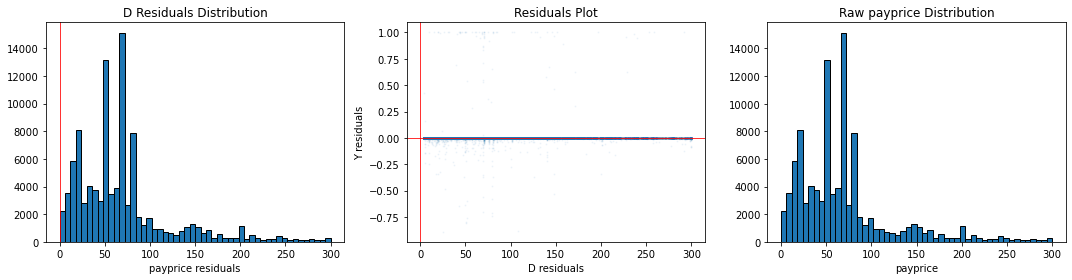

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(D_res, bins=50, edgecolor='k')
axes[0].axvline(0, color='red', linewidth=0.8)
axes[0].set_title('D Residuals Distribution')
axes[0].set_xlabel('payprice residuals')

axes[1].scatter(D_res, Y_res, alpha=0.05, s=1)
axes[1].axhline(0, color='red', linewidth=0.8)
axes[1].axvline(0, color='red', linewidth=0.8)
axes[1].set_title('Residuals Plot')
axes[1].set_xlabel('D residuals')
axes[1].set_ylabel('Y residuals')

axes[2].hist(sample_df['payprice'], bins=50, edgecolor='k')
axes[2].set_title('Raw payprice Distribution')
axes[2].set_xlabel('payprice')

plt.tight_layout()
plt.show()